In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
  sys.path.insert(0, str(ROOT))

import torch
from torchvision.io import read_image, ImageReadMode

from src.datasets.fungitastic import FungiTasticDataset
from src.models.architectures.encdecnet import EncDecNetBackbone
from src.models.architectures.mobilenet_v3 import MobileNetV3
from src.models.segmentation_model import SegmentationModel

import matplotlib.pyplot as plt


In [2]:
ckpt_path = "../logs/encdecnet_segmenter_20260430_000122/epoch=4-step=4315.ckpt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# backbone = EncDecNetBackbone(
#   in_channels=3,
#   base_channels=32,
#   out_channels=32
# )
backbone = MobileNetV3()

model = SegmentationModel.load_from_checkpoint(
  ckpt_path,
  backbone=backbone,
  map_location="cpu"
)
model.to(device)
model.eval()

dataset = FungiTasticDataset('../data/FungiTastic', 'val')
print("Loaded dataset")



Loaded dataset


torch.Size([1, 3, 300, 300])


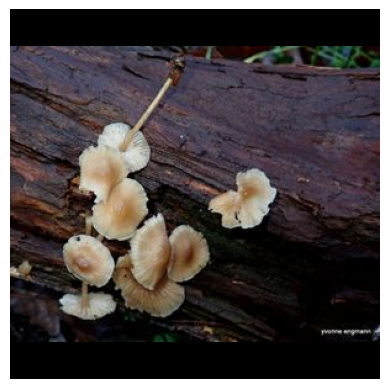

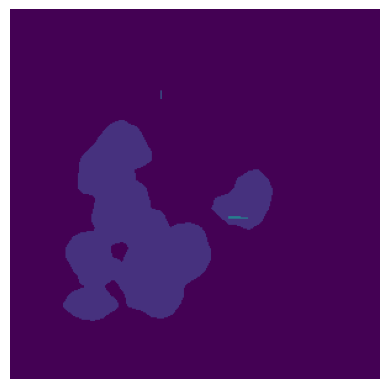

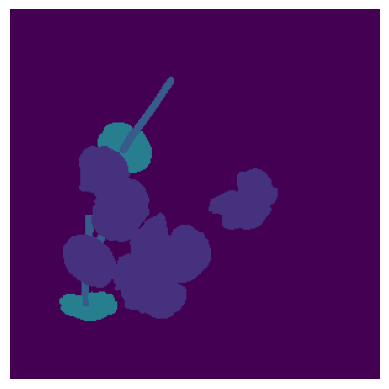

In [ ]:
image, mask = dataset[4]

image = image.view(1, 3, 300, 300).to(device)
print(image.shape)

with torch.inference_mode():
  logits = model(image)
  probs = torch.softmax(logits, 1)
  pred_mask = logits.argmax(1)[0]

pred_mask = pred_mask.detach().cpu().numpy()

image = image.view(3, 300, 300).permute(1, 2, 0)

plt.imshow(image.detach().cpu().numpy())
plt.axis('off')
plt.show()

plt.imshow(pred_mask, vmin=0, vmax=5)
plt.axis('off')
plt.show()

plt.imshow(mask, vmin=0, vmax=5)
plt.axis('off')
plt.show()